
## Mục tiêu & Kế hoạch
**Mục tiêu:** Xây dựng pipeline E2E: EDA → Tiền xử lý → CV baseline → Tuning (Randomized + Grid) → Đánh giá Test → Permutation Importance → Feature Selection → Lưu mô hình & Inference.

**Chỉ số chính:** `ROC-AUC`.  **Chỉ số phụ:** `PR-AUC`, `Accuracy`, `F1`, `Precision`, `Recall`.

**Kế hoạch tóm tắt:**
1) Đọc & làm sạch dữ liệu (coerce `TotalCharges`).  
2) EDA ngắn gọn (phân bố nhãn).  
3) X, y, nhóm cột (num/cat).  
4) Tiền xử lý (impute + OHE).  
5) Baseline CV cho Tree/RF.  
6) Tuning siêu tham số (Randomized → Grid nhỏ quanh best).  
7) Đánh giá test set & vẽ ROC/PR.  
8) Permutation Importance (đúng trên **không gian sau OHE**).  
9) Feature Selection (SelectFromModel-RF).  
10) Lưu mô hình & Inference.


### 1) Phân tích yêu cầu

Bài toán: phân loại nhị phân churn viễn thông.

Phạm vi: EDA ngắn; tiền xử lý (impute + OHE); chia train/test; CV; tuning (Randomized + Grid); đánh giá hold-out (ROC/PR/F1…); Permutation Importance; Feature Selection; lưu mô hình; inference.

Bổ sung: trực quan hóa Decision Tree và một cây trong Random Forest; chuẩn hóa input khi suy luận.

### 2) Hướng triển khai

Quy trình end-to-end trong Pipeline: ColumnTransformer (số: median impute; loại: most_frequent + OHE) → mô hình.

StratifiedKFold (k=5); tối ưu theo ROC-AUC.

RandomizedSearchCV dò rộng, GridSearchCV tinh chỉnh quanh điểm tốt nhất (ràng buộc lưới không rỗng).

Permutation Importance trên không gian sau OHE; SelectFromModel (RF) cho giảm chiều.

Lưu joblib; inference với hàm chuẩn hóa schema đầu vào.

### 3) Mô hình

DecisionTreeClassifier: baseline/diễn giải.

RandomForestClassifier: mô hình chính (độ ổn định và ROC-AUC cao hơn).

### 4) Cấu hình & tham số (rút gọn)

Chia dữ liệu: test_size=0.2, stratify=y, random_state=42.

Scoring: roc_auc; báo cáo thêm PR-AUC, Accuracy, F1, Precision, Recall.

Tuning (ví dụ điển hình):

Tree: criterion∈{gini,entropy,log_loss}, max_depth, min_samples_split/leaf, class_weight∈{None,balanced}.

RF: n_estimators≈150–500, max_depth, min_samples_split/leaf, max_features∈{sqrt,log2,0.3,0.5,0.7}, class_weight.

### 5) Kết quả (lần chạy minh họa)

ROC-AUC (test, mô hình nạp từ file): 0.8433.

Ví dụ suy luận: xác suất churn ≈ 0.576 → nhãn Yes (1).

## 0) Import & Cấu hình

In [1]:

import os, sys, warnings, json
from pathlib import Path
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,
    classification_report, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix
)
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt

import joblib
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def plot_roc_curve(y_true, y_prob, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

def plot_pr_curve(y_true, y_prob, title="Precision-Recall Curve"):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    plt.figure()
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend(loc="lower left")
    plt.show()

def report_metrics(y_true, y_prob, y_pred, prefix=""):
    roc = roc_auc_score(y_true, y_prob)
    ap  = average_precision_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    print(f"{prefix}ROC-AUC: {roc:.4f}\n{prefix}PR-AUC: {ap:.4f}\n{prefix}Accuracy: {acc:.4f}\n{prefix}F1: {f1:.4f}\n{prefix}Precision: {pre:.4f}\n{prefix}Recall: {rec:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

def find_telco_csv(data_dir: Path) -> Path:
    candidates = [
        "WA_Fn-UseC_-Telco-Customer-Churn.csv",
        "Telco-Customer-Churn.csv",
        "telco.csv",
        "Telco.csv",
    ]
    for name in candidates:
        p = data_dir / name
        if p.exists():
            return p
    for p in data_dir.glob("*.csv"):
        try:
            head = pd.read_csv(p, nrows=5)
            if "Churn" in head.columns:
                return p
        except Exception:
            pass
    raise FileNotFoundError(f"Không tìm thấy file Telco CSV trong {data_dir}. Hãy đặt file Kaggle vào thư mục này.")


## 1) Đọc dữ liệu & EDA ngắn gọn

Đang sử dụng file: Data\CSV\Telco\Telco-Customer-Churn Prediction.csv
Kích thước: (7043, 21)
Các cột (mẫu): ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection']

Phân bố nhãn Churn:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64
Tỉ lệ Yes: 0.2653698707936959


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


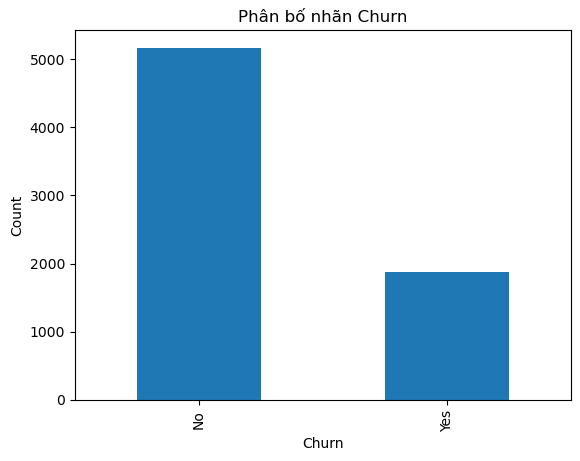

In [2]:

DATA_DIR = Path("Data/CSV/Telco"); DATA_DIR.mkdir(exist_ok=True)
csv_path = find_telco_csv(DATA_DIR)
print("Đang sử dụng file:", csv_path)

df = pd.read_csv(csv_path)

if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Kích thước:", df.shape)
print("Các cột (mẫu):", list(df.columns[:12]))

print("\nPhân bố nhãn Churn:\n", df['Churn'].value_counts(dropna=False))
print("Tỉ lệ Yes:", (df['Churn'] == 'Yes').mean())

numeric_cols_guess = df.select_dtypes(include=[np.number]).columns.tolist()
display(df[numeric_cols_guess].describe().T)

vc = df['Churn'].value_counts()
plt.figure()
vc.plot(kind='bar')
plt.title('Phân bố nhãn Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()


## 2) Chuẩn bị X, y và nhóm cột

In [3]:

y = (df['Churn'] == 'Yes').astype(int)
drop_cols = [c for c in ['Churn','customerID'] if c in df.columns]
X = df.drop(columns=drop_cols)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

print("Số cột số:", len(num_cols), "| Số cột phân loại:", len(cat_cols))


Số cột số: 4 | Số cột phân loại: 15


## 3) Pipeline tiền xử lý

In [4]:

from sklearn.preprocessing import OneHotEncoder

numeric_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
])

try:
    _ = OneHotEncoder(sparse_output=False)
    categorical_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
except TypeError:
    categorical_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ])

transformers = []
if len(num_cols) > 0:
    transformers.append(('num', numeric_pipe, num_cols))
if len(cat_cols) > 0:
    transformers.append(('cat', categorical_pipe, cat_cols))
if not transformers:
    raise ValueError("Không có cột nào để xử lý!")

preprocessor = ColumnTransformer(transformers)


## 4) Chia train/test

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_test.shape, y_train.mean(), y_test.mean()


((5634, 19),
 (1409, 19),
 np.float64(0.2653532126375577),
 np.float64(0.2654364797728886))

## 5) Baseline Cross‑Validation

In [6]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_score(model, name):
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=['roc_auc','accuracy','f1'],
        n_jobs=-1, return_train_score=False
    )
    res = pd.DataFrame(scores).agg(['mean','std']).T
    print(f"\n>>> {name}\n", res)
    return res

res_tree = cv_score(DecisionTreeClassifier(random_state=42), "DecisionTree (gini)")
res_rf   = cv_score(RandomForestClassifier(random_state=42), "RandomForest (baseline)")



>>> DecisionTree (gini)
                    mean       std
fit_time       0.075140  0.004661
score_time     0.027983  0.003845
test_roc_auc   0.657041  0.012360
test_accuracy  0.729321  0.009494
test_f1        0.496802  0.018260

>>> RandomForest (baseline)
                    mean       std
fit_time       0.697395  0.010132
score_time     0.085964  0.004368
test_roc_auc   0.818432  0.013408
test_accuracy  0.784348  0.014996
test_f1        0.541330  0.030824


## 6) Tuning siêu tham số

In [7]:

tree_param_dist = {
    'clf__criterion': ['gini','entropy','log_loss'],
    'clf__max_depth': [None, 4, 6, 8, 10, 12, 16, 20],
    'clf__min_samples_split': [2, 5, 10, 20, 50],
    'clf__min_samples_leaf': [1, 2, 4, 8, 12, 16],
    'clf__class_weight': [None, 'balanced']
}
tree_pipe = Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(random_state=42))])
tree_rand = RandomizedSearchCV(
    tree_pipe, param_distributions=tree_param_dist, n_iter=50,
    scoring='roc_auc', cv=cv, n_jobs=-1, random_state=42, verbose=0
)
tree_rand.fit(X_train, y_train)
print("Best Tree AUC:", tree_rand.best_score_)
print("Best Tree Params:", tree_rand.best_params_)

rf_param_dist = {
    'clf__n_estimators': np.arange(150, 501, 10),
    'clf__max_depth': [None, 6, 8, 10, 12, 16, 20],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__min_samples_leaf': [1, 2, 4, 8],
    'clf__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'clf__class_weight': [None, 'balanced']
}
rf_pipe = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(random_state=42))])
rf_rand = RandomizedSearchCV(
    rf_pipe, param_distributions=rf_param_dist, n_iter=60,
    scoring='roc_auc', cv=cv, n_jobs=-1, random_state=42, verbose=0
)
rf_rand.fit(X_train, y_train)
print("Best RF AUC:", rf_rand.best_score_)
print("Best RF Params:", rf_rand.best_params_)

best_tree = tree_rand.best_estimator_
best_rf   = rf_rand.best_estimator_


Best Tree AUC: 0.828730100985023
Best Tree Params: {'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': 4, 'clf__criterion': 'entropy', 'clf__class_weight': None}
Best RF AUC: 0.8481830116925082
Best RF Params: {'clf__n_estimators': np.int64(160), 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 8, 'clf__max_features': 'sqrt', 'clf__max_depth': 8, 'clf__class_weight': None}


### 6.1) GridSearch tinh chỉnh an toàn

In [8]:

def sanitize_param_grid(pipe, best_params, params_gs):
    pipe.set_params(**best_params)
    clean = {}
    for k, vals in params_gs.items():
        if vals is None:
            continue
        if not isinstance(vals, (list, tuple, np.ndarray)):
            vals = [vals]
        vals = list(vals)
        if k.endswith('n_estimators'):
            vals = [max(50, int(v)) for v in vals if v is not None]
        uniq = []
        for v in vals:
            if v not in uniq:
                uniq.append(v)
        if len(uniq) > 0:
            clean[k] = uniq
    return clean

best_ne = rf_rand.best_params_['clf__n_estimators']
params_gs_raw = {
    'clf__n_estimators': [best_ne-50, best_ne, best_ne+50],
    'clf__max_depth': [rf_rand.best_params_.get('clf__max_depth', None)],
    'clf__min_samples_split': [rf_rand.best_params_['clf__min_samples_split']],
    'clf__min_samples_leaf': [rf_rand.best_params_['clf__min_samples_leaf']],
    'clf__max_features': [rf_rand.best_params_['clf__max_features']],
    'clf__class_weight': [rf_rand.best_params_.get('clf__class_weight', None)],
}

rf_pipe_gs = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(random_state=42))])
params_gs = sanitize_param_grid(rf_pipe_gs, rf_rand.best_params_, params_gs_raw)

rf_grid = GridSearchCV(rf_pipe_gs, param_grid=params_gs, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)
print("[Grid] Best RF AUC:", rf_grid.best_score_)
print("[Grid] Best RF Params:", rf_grid.best_params_)

best_rf = rf_grid.best_estimator_


[Grid] Best RF AUC: 0.8481830116925082
[Grid] Best RF Params: {'clf__class_weight': None, 'clf__max_depth': 8, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 10, 'clf__n_estimators': 160}


## 7) Đánh giá trên Test set


=== Decision Tree (tuned) ===
Test ROC-AUC: 0.8285
Test PR-AUC: 0.6010
Test Accuracy: 0.7921
Test F1: 0.5357
Test Precision: 0.6576
Test Recall: 0.4519

Classification Report:
               precision    recall  f1-score   support

           0     0.8220    0.9150    0.8660      1035
           1     0.6576    0.4519    0.5357       374

    accuracy                         0.7921      1409
   macro avg     0.7398    0.6834    0.7008      1409
weighted avg     0.7784    0.7921    0.7783      1409



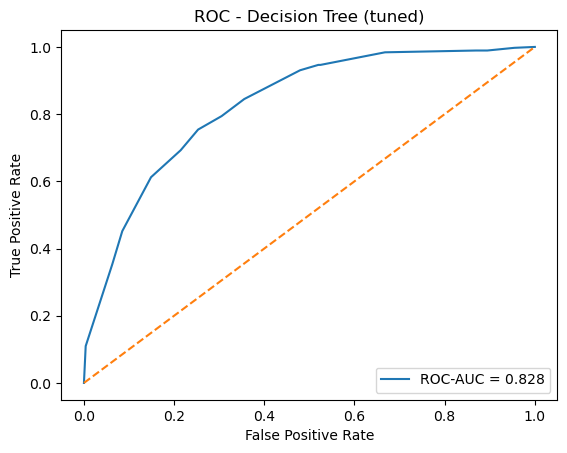

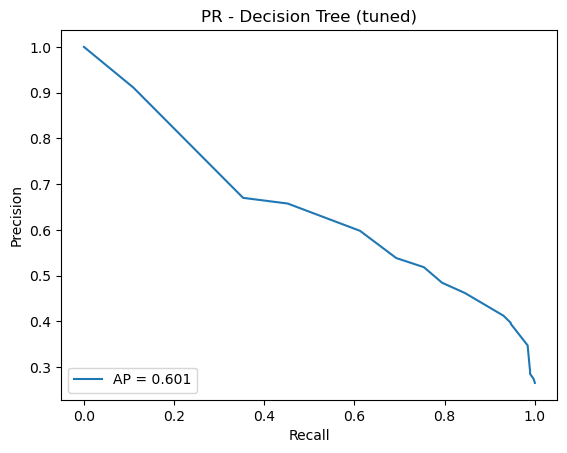

Confusion Matrix:
 [[947  88]
 [205 169]]

=== Random Forest (tuned) ===
Test ROC-AUC: 0.8433
Test PR-AUC: 0.6578
Test Accuracy: 0.8077
Test F1: 0.5811
Test Precision: 0.6886
Test Recall: 0.5027

Classification Report:
               precision    recall  f1-score   support

           0     0.8363    0.9179    0.8752      1035
           1     0.6886    0.5027    0.5811       374

    accuracy                         0.8077      1409
   macro avg     0.7625    0.7103    0.7282      1409
weighted avg     0.7971    0.8077    0.7971      1409



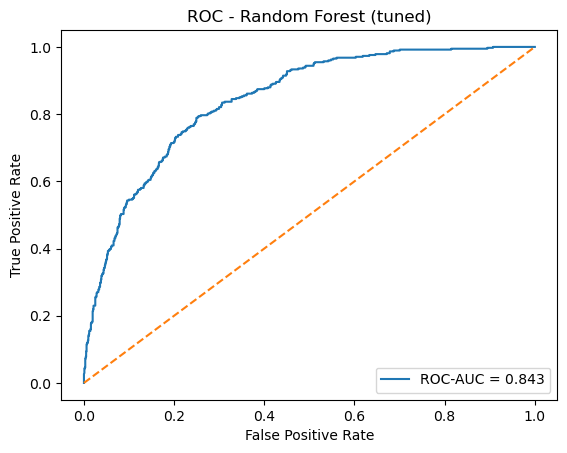

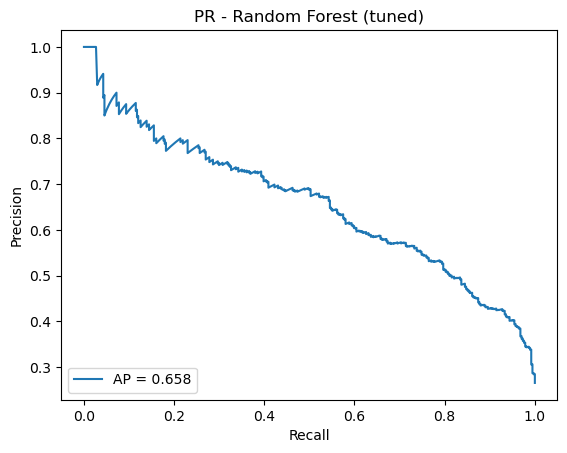

Confusion Matrix:
 [[950  85]
 [186 188]]


,roc_auc,pr_auc,accuracy,f1
Random Forest (tuned),0.843269,0.657770,0.807665,0.581144
Decision Tree (tuned),0.828493,0.600985,0.792051,0.535658


In [9]:

models = {
    'Decision Tree (tuned)': best_tree,
    'Random Forest (tuned)': best_rf
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob >= 0.5).astype(int)
    print("\n===", name, "===")
    report_metrics(y_test, y_prob, y_pred, prefix="Test ")
    plot_roc_curve(y_test, y_prob, title=f"ROC - {name}")
    plot_pr_curve(y_test, y_prob, title=f"PR - {name}")
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)
    results[name] = {
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc': average_precision_score(y_test, y_prob),
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }

pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)


## 8) Tên đặc trưng sau tiền xử lý

In [10]:

def get_feature_names_from_ct(ct: ColumnTransformer) -> np.ndarray:
    feature_names = []
    for name, trans, cols in ct.transformers_:
        if name == 'remainder':
            continue
        if hasattr(trans, 'get_feature_names_out'):
            try:
                fn = trans.get_feature_names_out(cols)
                feature_names.extend(list(fn))
                continue
            except Exception:
                pass
        if isinstance(trans, Pipeline):
            last = trans.steps[-1][1]
            if hasattr(last, 'get_feature_names_out'):
                try:
                    fn = last.get_feature_names_out(cols)
                    feature_names.extend(list(fn))
                    continue
                except Exception:
                    pass
        feature_names.extend(list(cols))
    return np.array(feature_names)

ct = best_rf.named_steps['prep']
feat_names = get_feature_names_from_ct(ct)
len(feat_names), feat_names[:10]


(45,
 array(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
        'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes',
        'Dependents_No', 'Dependents_Yes'], dtype='<U39'))

## 9) Permutation Importance trên không gian **sau OHE**

In [11]:

prep = best_rf.named_steps['prep']
clf  = best_rf.named_steps['clf']

_ = best_rf.fit(X_train, y_train)

X_test_t = prep.transform(X_test)
perm = permutation_importance(clf, X_test_t, y_test, scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=-1)

imp = pd.DataFrame({
    'feature': feat_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)
imp.head(20)


,feature,importance_mean,importance_std
1,tenure,0.026476,0.001893
36,Contract_Month-to-month,0.016769,0.003646
3,TotalCharges,0.014774,0.002142
16,InternetService_Fiber optic,0.006117,0.003180
38,Contract_Two year,0.003835,0.001021
18,OnlineSecurity_No,0.003171,0.001451
43,PaymentMethod_Electronic check,0.000975,0.000861
27,TechSupport_No,0.000943,0.001022
37,Contract_One year,0.000556,0.000842
39,PaperlessBilling_No,0.000378,0.000502


## 10) Feature Selection / Reduction

[FS] Best CV AUC: 0.8470586857089304

=== Random Forest + SelectFromModel ===
Test ROC-AUC: 0.8435
Test PR-AUC: 0.6547
Test Accuracy: 0.8020
Test F1: 0.5714
Test Precision: 0.6715
Test Recall: 0.4973

Classification Report:
               precision    recall  f1-score   support

           0     0.8339    0.9121    0.8713      1035
           1     0.6715    0.4973    0.5714       374

    accuracy                         0.8020      1409
   macro avg     0.7527    0.7047    0.7213      1409
weighted avg     0.7908    0.8020    0.7917      1409



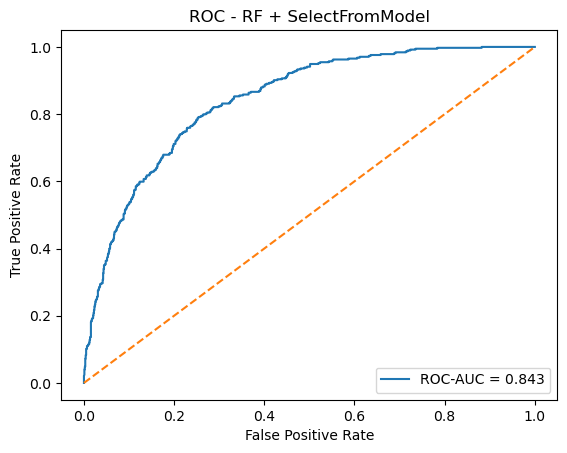

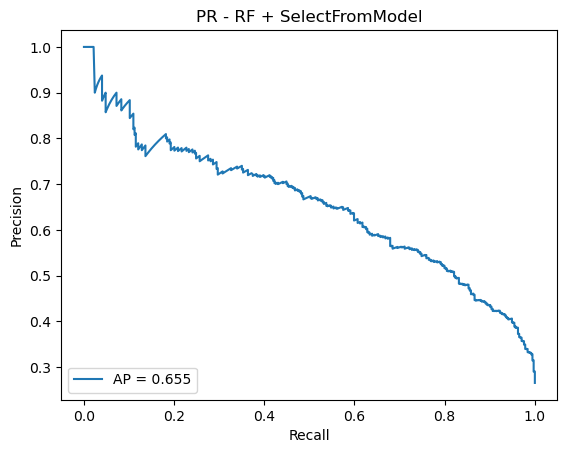

In [12]:

selector = SelectFromModel(RandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1
), threshold='median')

pipe_fs = Pipeline([
    ('prep', preprocessor),
    ('sel', selector),
    ('clf', RandomForestClassifier(random_state=42))
])

param_dist_fs = {
    'clf__n_estimators': np.arange(200, 501, 20),
    'clf__max_depth': [None, 8, 10, 12, 16, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2', 0.5],
    'clf__class_weight': [None, 'balanced']
}

fs_rand = RandomizedSearchCV(
    pipe_fs, param_distributions=param_dist_fs, n_iter=40,
    scoring='roc_auc', cv=cv, n_jobs=-1, random_state=42, verbose=0
)
fs_rand.fit(X_train, y_train)
best_fs = fs_rand.best_estimator_
print("[FS] Best CV AUC:", fs_rand.best_score_)

y_prob = best_fs.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.5).astype(int)
print("\n=== Random Forest + SelectFromModel ===")
report_metrics(y_test, y_prob, y_pred, prefix="Test ")
plot_roc_curve(y_test, y_prob, title="ROC - RF + SelectFromModel")
plot_pr_curve(y_test, y_prob, title="PR - RF + SelectFromModel")


## 11) Lưu mô hình & Inference

In [13]:

MODELS_DIR = Path("models"); MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(best_rf, MODELS_DIR / "rf_best_pipeline.joblib")
joblib.dump(best_tree, MODELS_DIR / "tree_best_pipeline.joblib")
print("Đã lưu mô hình trong:", MODELS_DIR.resolve())

def predict_churn(df_new: pd.DataFrame, model_path: Path) -> np.ndarray:
    pipe = joblib.load(model_path)
    proba = pipe.predict_proba(df_new)[:,1]
    return proba

proba_demo = predict_churn(X_test.head(5), MODELS_DIR / "rf_best_pipeline.joblib")
proba_demo


Đã lưu mô hình trong: E:\.Data\Documents\Code\4. Python\AI_Introduct\models


array([0.02792312, 0.65650531, 0.07141651, 0.3493938 , 0.03964487])


## Ghi chú sửa lỗi & tính tương thích
- **GridSearchCV**: tránh danh sách rỗng bằng `sanitize_param_grid`; giữ `[None]` hợp lệ.
- **OneHotEncoder**: hỗ trợ cả sklearn >=1.2 (`sparse_output=False`) và cũ hơn (`sparse=False`) bằng `try/except`.
- **Permutation Importance**: tính **trên không gian đã OHE** (`prep.transform(X)` + `clf`) để **khớp** số lượng đặc trưng với `feat_names`.
- **ColumnTransformer**: chỉ thêm transformer khi nhóm cột **không rỗng**.
- **Rò rỉ dữ liệu**: impute & OHE nằm trong Pipeline/CV để tránh leakage.


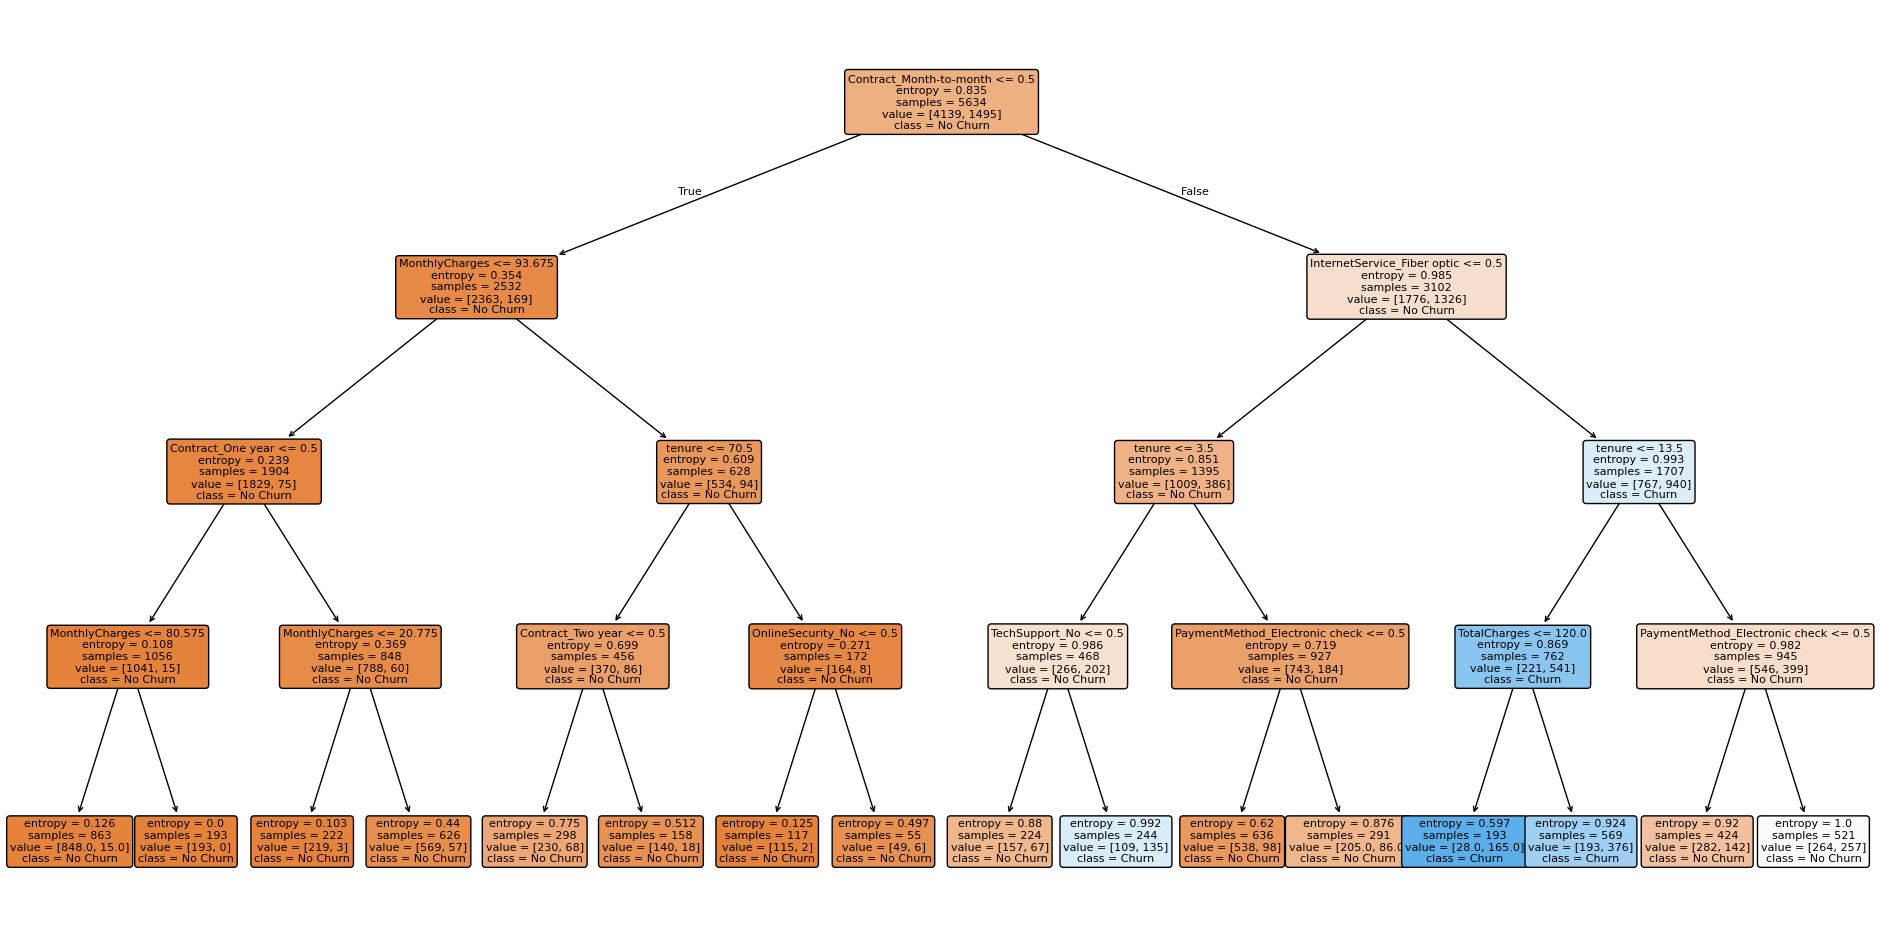

|--- Contract_Month-to-month <= 0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- Contract_One year <= 0.50
|   |   |   |--- MonthlyCharges <= 80.58
|   |   |   |   |--- class: 0
|   |   |   |--- MonthlyCharges >  80.58
|   |   |   |   |--- class: 0
|   |   |--- Contract_One year >  0.50
|   |   |   |--- MonthlyCharges <= 20.77
|   |   |   |   |--- class: 0
|   |   |   |--- MonthlyCharges >  20.77
|   |   |   |   |--- class: 0
|   |--- MonthlyCharges >  93.67
|   |   |--- tenure <= 70.50
|   |   |   |--- Contract_Two year <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Contract_Two year >  0.50
|   |   |   |   |--- class: 0
|   |   |--- tenure >  70.50
|   |   |   |--- OnlineSecurity_No <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- OnlineSecurity_No >  0.50
|   |   |   |   |--- class: 0
|--- Contract_Month-to-month >  0.50
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- tenure <= 3.50
|   |   |   |--- TechSupport_No <= 0.50
|   |   |   |   |--- class: 0
|   |

In [14]:
from sklearn import tree

# best_tree là pipeline: prep + clf
clf_tree = best_tree.named_steps['clf']

plt.figure(figsize=(24,12))
tree.plot_tree(
    clf_tree,
    filled=True,
    feature_names=get_feature_names_from_ct(best_tree.named_steps['prep']),
    class_names=['No Churn', 'Churn'],
    rounded=True,
    fontsize=8
)
plt.show()

# Hoặc in ra text
tree_text = tree.export_text(
    clf_tree,
    feature_names=list(get_feature_names_from_ct(best_tree.named_steps['prep']))
)
print(tree_text[:2000])  # in 2000 ký tự đầu


In [15]:
# ## 12) Sử dụng mô hình đã lưu để dự đoán
import joblib

# Nạp lại mô hình Random Forest tốt nhất từ file
rf_loaded = joblib.load("models/rf_best_pipeline.joblib")

# Dự đoán trên tập test đã chuẩn bị ở phase trước
y_prob_loaded = rf_loaded.predict_proba(X_test)[:,1]
y_pred_loaded = rf_loaded.predict(X_test)

print("Xác suất churn (5 khách đầu):", y_prob_loaded[:5])
print("Dự đoán nhãn:", y_pred_loaded[:5])

# So sánh nhanh với y_test
from sklearn.metrics import roc_auc_score
print("ROC-AUC (loaded model):", roc_auc_score(y_test, y_prob_loaded))


Xác suất churn (5 khách đầu): [0.02792312 0.65650531 0.07141651 0.3493938  0.03964487]
Dự đoán nhãn: [0 1 0 0 0]
ROC-AUC (loaded model): 0.8432690072076261


In [16]:
# Lấy đúng danh sách cột gốc (đã dùng để train X)
expected_cols = X.columns.tolist()

# Tạo input mới, bắt buộc đủ cột
new_customers = pd.DataFrame([{
    "customerID": "0001-A",
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 12,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 70.35,
    "TotalCharges": 845.50
}], columns=expected_cols)

def prepare_input(df_new, ref_columns):
    df_new = df_new.copy()
    for col in ref_columns:
        if col not in df_new.columns:
            df_new[col] = np.nan
    return df_new[ref_columns]

# Chuẩn hóa input trước khi dự đoán
df_ready = prepare_input(new_customers, X.columns)
proba_new = rf_loaded.predict_proba(df_ready)[:,1]
print("Xác suất churn:", proba_new)

Xác suất churn: [0.58070194]



## 12) Trực quan hóa cấu trúc cây (Decision Tree & Random Forest)
- Vẽ **cây quyết định** đã tinh chỉnh (`best_tree`).
- Vẽ **một cây** đại diện trong **Random Forest** (`best_rf`).
- Có thể giới hạn `max_depth` để đồ thị dễ đọc.


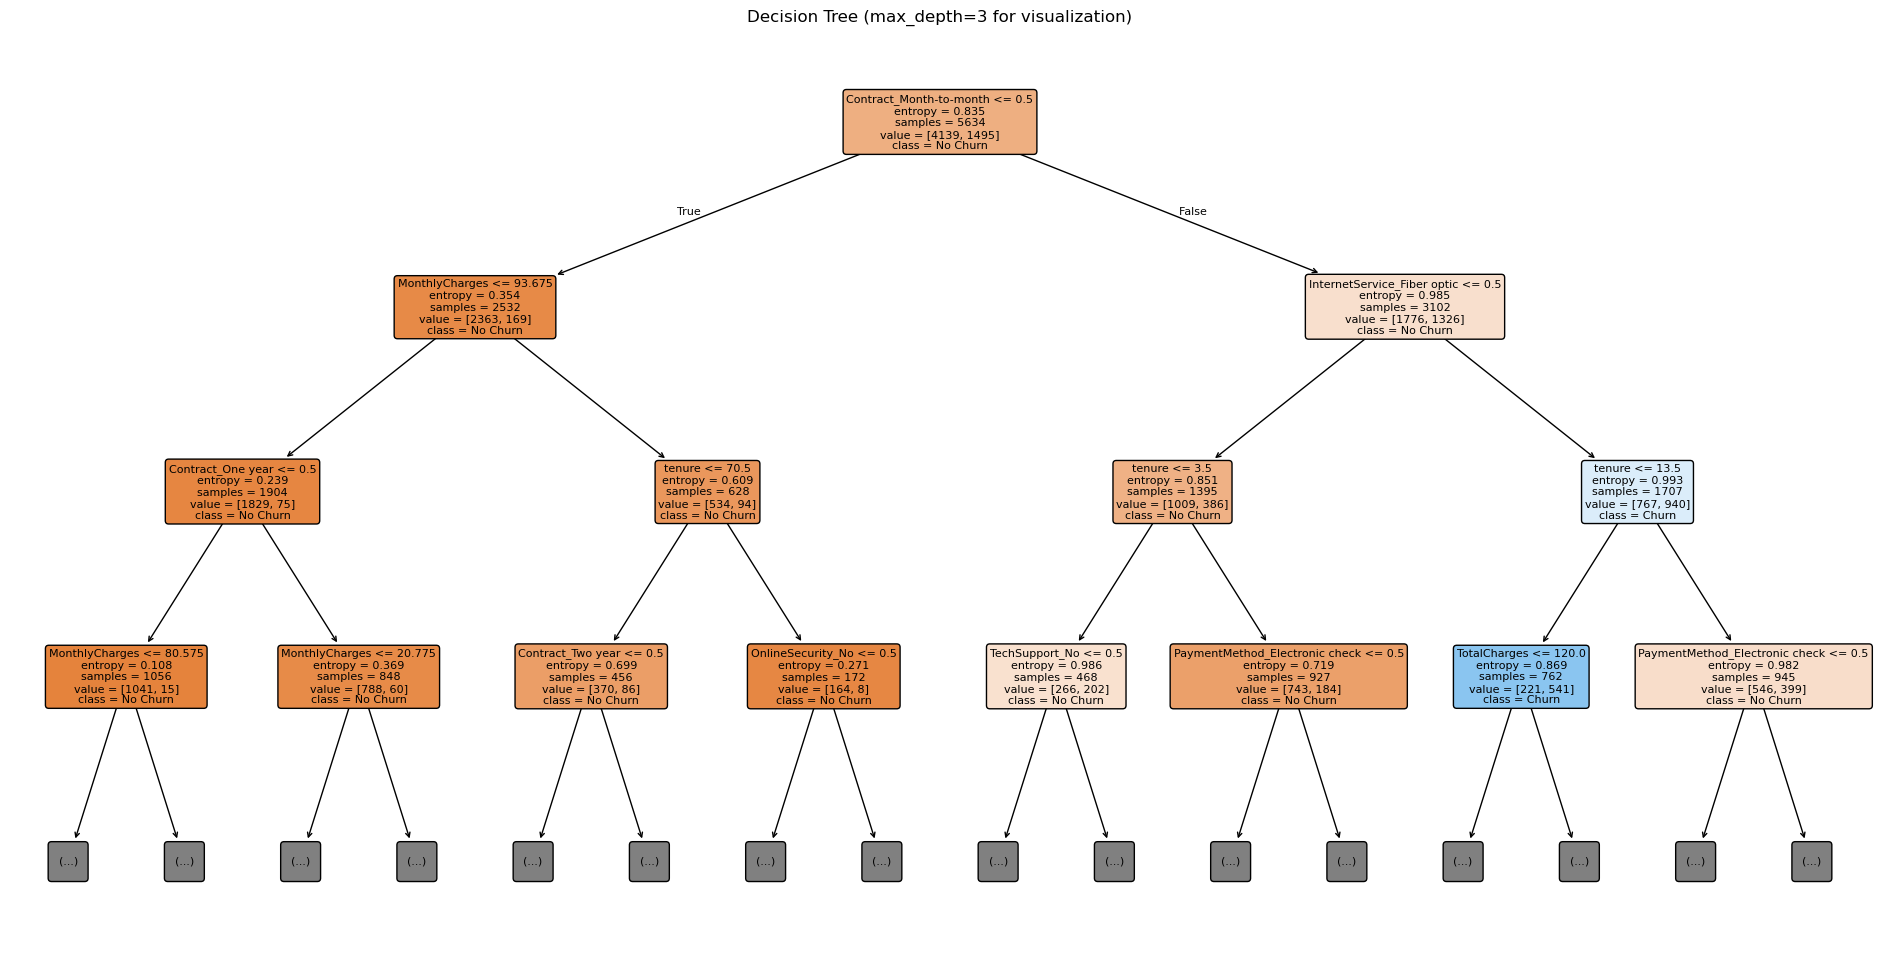

|--- Contract_Month-to-month <= 0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- Contract_One year <= 0.50
|   |   |   |--- MonthlyCharges <= 80.58
|   |   |   |   |--- class: 0
|   |   |   |--- MonthlyCharges >  80.58
|   |   |   |   |--- class: 0
|   |   |--- Contract_One year >  0.50
|   |   |   |--- MonthlyCharges <= 20.77
|   |   |   |   |--- class: 0
|   |   |   |--- MonthlyCharges >  20.77
|   |   |   |   |--- class: 0
|   |--- MonthlyCharges >  93.67
|   |   |--- tenure <= 70.50
|   |   |   |--- Contract_Two year <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Contract_Two year >  0.50
|   |   |   |   |--- class: 0
|   |   |--- tenure >  70.50
|   |   |   |--- OnlineSecurity_No <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- OnlineSecurity_No >  0.50
|   |   |   |   |--- class: 0
|--- Contract_Month-to-month >  0.50
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- tenure <= 3.50
|   |   |   |--- TechSupport_No <= 0.50
|   |   |   |   |--- class: 0
|   |

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

# Trực quan hóa 1 cây từ Random Forest
clf_rf = best_rf.named_steps['clf']
estimator = clf_rf.estimators_[0]

prep_rf = best_rf.named_steps['prep']
try:
    feature_names_rf = get_feature_names_from_ct(prep_rf)
except NameError:
    feature_names_rf = getattr(prep_rf, 'feature_names_in_', None)
    if feature_names_rf is None:
        feature_names_rf = [f"f{i}" for i in range(getattr(estimator, 'n_features_in_', 0))]

plt.figure(figsize=(24, 12))
tree.plot_tree(
    estimator,
    filled=True,
    feature_names=list(feature_names_rf) if feature_names_rf is not None else None,
    class_names=['No Churn', 'Churn'],
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Random Forest — one estimator (max_depth=3 for visualization)")
plt.show()

# Xuất text của cây RF
rf_tree_text = tree.export_text(
    estimator,
    feature_names=list(feature_names_rf) if feature_names_rf is not None else None,
    max_depth=3
)
print(rf_tree_text[:3000])



## 13) Sử dụng mô hình đã lưu để dự đoán
- Nạp lại pipeline đã lưu bằng `joblib.load`.
- **Chuẩn hoá schema**: tự động thêm cột còn thiếu so với lúc train.
- Trả về **xác suất churn** cho dữ liệu mới.


In [21]:

import numpy as np, pandas as pd, joblib
from sklearn.metrics import roc_auc_score

def prepare_input(df_new: pd.DataFrame, ref_columns) -> pd.DataFrame:
    """Đảm bảo df_new có đầy đủ cột như lúc train (thứ tự cột giống ref_columns).
    Các cột thiếu sẽ được thêm và gán NaN để pipeline imputer xử lý.
    """
    df_new = df_new.copy()
    for col in ref_columns:
        if col not in df_new.columns:
            df_new[col] = np.nan
    return df_new[ref_columns]

# Nạp mô hình (Random Forest tốt nhất)
rf_loaded = joblib.load("models/rf_best_pipeline.joblib")

# Lấy danh sách cột gốc từ phase trước
ref_cols = X.columns.tolist()

# Ví dụ dữ liệu mới (thiếu nhiều cột -> vẫn OK nhờ prepare_input)
new_customers = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 12,
    "PhoneService": "Yes",
    "InternetService": "Fiber optic",
    "MonthlyCharges": 70.35,
    "TotalCharges": 845.50
}])

df_ready = prepare_input(new_customers, ref_cols)
y_prob_loaded = rf_loaded.predict_proba(df_ready)[:, 1]
y_pred_loaded = (y_prob_loaded >= 0.5).astype(int)

print("Xác suất churn:", y_prob_loaded)

label_map = {0: "No", 1: "Yes"}
print("Dự đoán nhãn:", [label_map[v] for v in y_pred_loaded])

# So sánh nhanh trên tập test (đã có từ phase trước)
df_test_ready = prepare_input(X_test, ref_cols)
y_prob_test = rf_loaded.predict_proba(df_test_ready)[:, 1]
print("ROC-AUC (loaded model trên test):", roc_auc_score(y_test, y_prob_test))


Xác suất churn: [0.57592805]
Dự đoán nhãn: ['Yes']
ROC-AUC (loaded model trên test): 0.8432690072076261
